<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/01_tabular_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeiro olhar sobre o nosso conjunto de dados

Neste notebook, vemos os passos necessários antes que qualquer aprendizado de
máquina aconteça. Isso envolve:

* carregar os dados;
* observar as variáveis do conjunto de dados, em particular, diferenciar entre
  variáveis numéricas e categóricas, que exigem pré-processamentos distintos
  na maioria dos fluxos de trabalho de machine learning;
* visualizar a distribuição das variáveis para obter algumas percepções sobre
  o conjunto de dados.

## Carregando o conjunto de dados do censo norte-americano

Usamos dados do censo dos Estados Unidos de 1994, que baixamos do
[OpenML](http://openml.org/).

Você pode consultar a página do OpenML para saber mais sobre este conjunto de
dados: <http://www.openml.org/d/1590>

O conjunto de dados está disponível como um arquivo CSV (Comma-Separated
Values) e usamos o `pandas` para lê-lo.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">O <a class="reference external" href="https://pandas.pydata.org/">Pandas</a> é uma biblioteca Python usada para
manipular dados estruturados de 1 e 2 dimensões. Se você nunca usou o pandas,
recomendamos que veja este
<a class="reference external" href="https://pandas.pydata.org/docs/user_guide/10min.html">tutorial</a>.</p>
</div>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

100%|██████████| 450k/450k [00:00<00:00, 1.33MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [ ]:
import pandas as pd
import os

# Assuming 'adult.csv' is the main data file within the downloaded directory
adult_census = pd.read_csv(os.path.join(path, "adult.csv"))

O objetivo com estes dados é prever se uma pessoa ganha mais de 50 mil por ano
a partir de dados heterogêneos como idade, emprego, escolaridade, informações
familiares etc.

## As variáveis (colunas) do conjunto de dados

Os dados estão armazenados em um dataframe do `pandas`. Um dataframe é um tipo
de dado estruturado composto por 2 dimensões. Esse tipo de dado também é
chamado de dado tabular.

Cada linha representa uma "amostra" (sample). Na área de aprendizado de
máquina ou de estatística descritiva, termos equivalentes de uso comum são
"registro", "instância" ou "observação".

Cada coluna representa um tipo de informação que foi coletada e é chamada de
"feature". Na área de aprendizado de máquina e de estatística descritiva,
termos equivalentes de uso comum são "variável", "atributo" ou "covariável".

Uma forma rápida de inspecionar o dataframe é mostrar as primeiras linhas com
o método `head`:

In [ ]:
adult_census.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Uma alternativa é omitir o método `head`. Isso exibiria as linhas e colunas
iniciais e finais, mas tudo o que está entre elas não é mostrado por padrão.
Também informa as dimensões do dataframe na parte de baixo, no formato
`n_rows` x `n_columns`.

In [ ]:
adult_census

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


A coluna chamada **income** é a nossa variável alvo (isto é, a variável que
queremos prever). As duas classes possíveis são `<=50K` (renda baixa) e `>50K`
(renda alta). O problema de previsão resultante é, portanto, um problema de
classificação binária, já que `class` tem apenas dois valores possíveis.
Usamos as demais colunas (qualquer coluna que não seja `class`) como variáveis
de entrada do nosso modelo.

In [ ]:
target_column = "income"
adult_census[target_column].value_counts()

,count
income,
<=50K,24720
>50K,7841


<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p>Aqui, as classes estão levemente desbalanceadas, o que significa que há mais
amostras de uma ou mais classes em comparação com as outras. Neste caso, temos
muito mais amostras com <tt class="docutils literal">" &lt;=50K"</tt> do que com <tt class="docutils literal">" &gt;50K"</tt>. O desbalanceamento de
classes acontece com frequência na prática e pode exigir técnicas especiais na
construção de um modelo preditivo.</p>
<p class="last">Por exemplo, em um contexto médico, se estivermos tentando prever se
indivíduos podem desenvolver uma doença rara, haveria muito mais indivíduos
saudáveis do que doentes no conjunto de dados.</p>
</div>

O conjunto de dados contém tanto dados numéricos quanto categóricos. Valores
numéricos assumem valores contínuos, por exemplo `"age"`. Valores categóricos
podem ter um número finito de valores, por exemplo `"native-country"`.

In [ ]:
numerical_columns = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
]
categorical_columns = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]
all_columns = numerical_columns + categorical_columns + [target_column]

adult_census = adult_census[all_columns]

Podemos verificar o número de amostras e o número de colunas disponíveis no
conjunto de dados:

In [ ]:
print(
    f"O conjunto de dados contém {adult_census.shape[0]} amostras e "
    f"{adult_census.shape[1]} colunas"
)

O conjunto de dados contém 32561 amostras e 14 colunas


Podemos calcular o número de features contando o número de colunas e
subtraindo 1, já que uma das colunas é o alvo.

In [ ]:
print(f"O conjunto de dados contém {adult_census.shape[1] - 1} features.")

O conjunto de dados contém 13 features.


## Inspeção visual dos dados
Antes de construir um modelo preditivo, é uma boa ideia olhar para os dados:

* talvez a tarefa que você está tentando realizar possa ser resolvida sem
  aprendizado de máquina;
* você precisa verificar se a informação de que precisa para a sua tarefa está
  de fato presente no conjunto de dados;
* inspecionar os dados é uma boa forma de encontrar peculiaridades. Elas podem
  surgir durante a coleta dos dados (por exemplo, um sensor com defeito ou
  valores ausentes) ou da forma como os dados são processados depois (por
  exemplo, valores truncados).

Vamos olhar a distribuição de cada feature individualmente, para obter algumas
percepções sobre os dados. Podemos começar plotando histogramas; note que isso
só funciona para features que contêm valores numéricos:

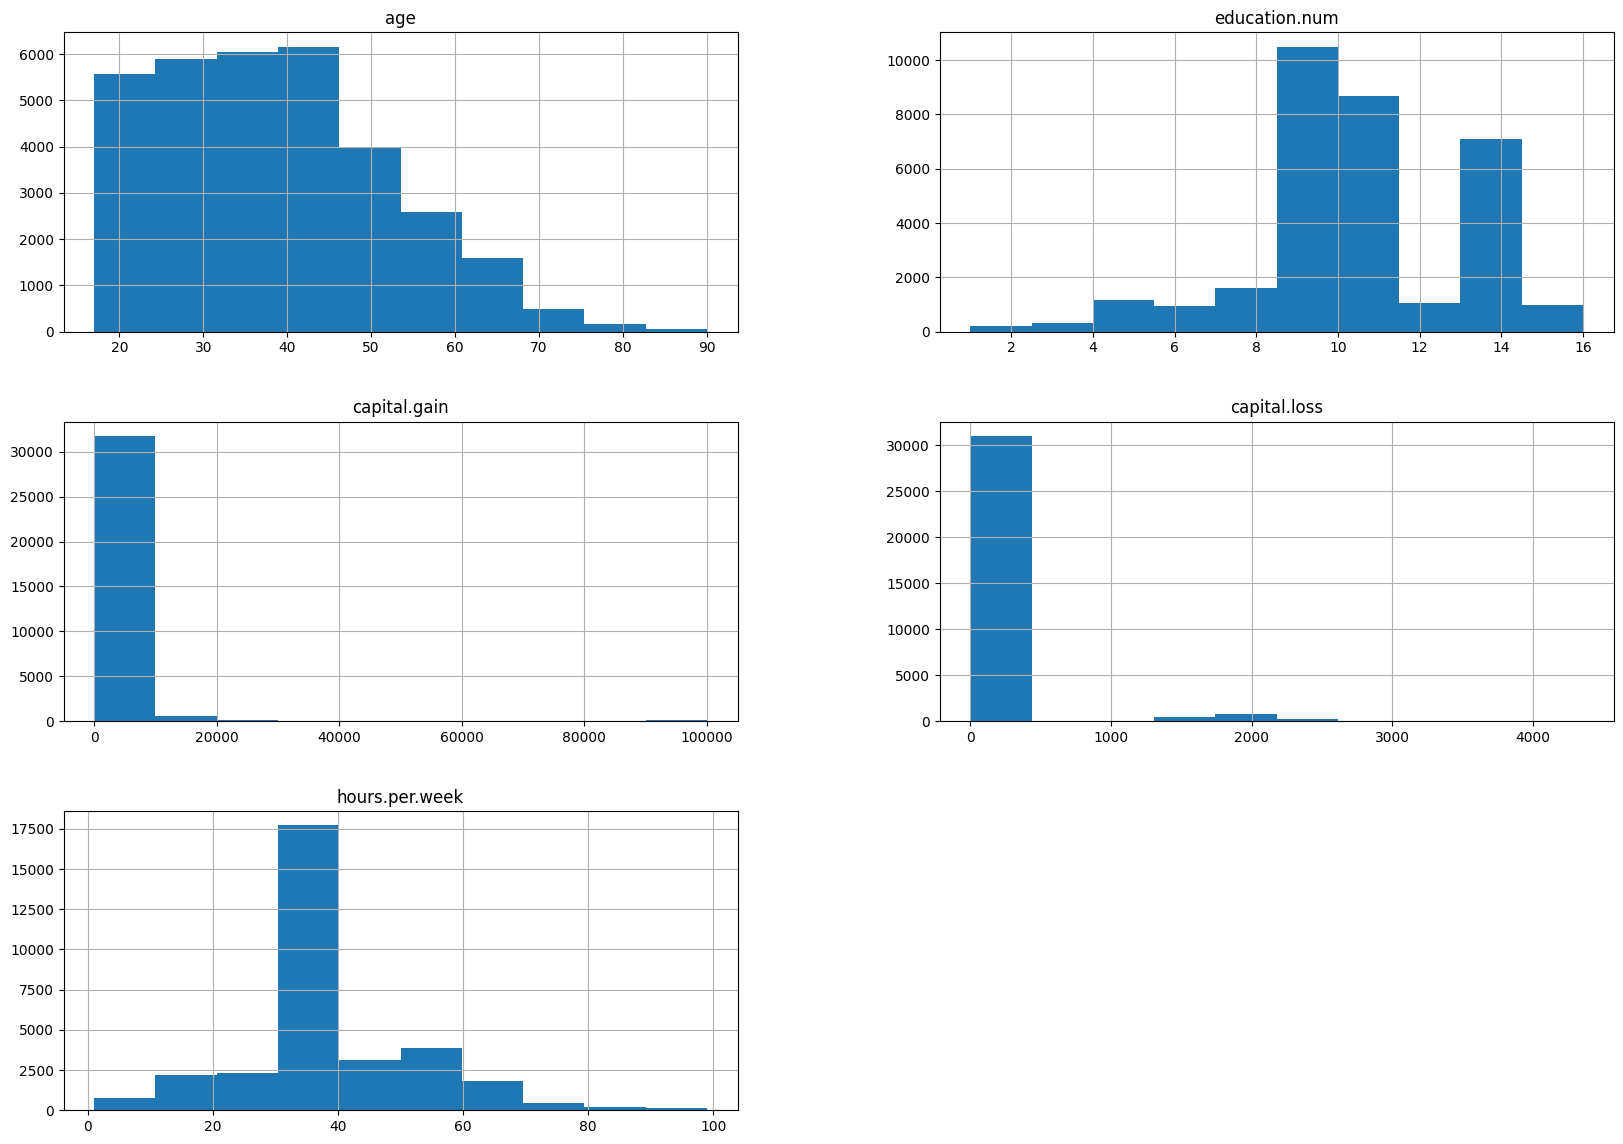

In [ ]:
_ = adult_census.hist(figsize=(20, 14))

<div class="admonition tip alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Dica</p>
<p class="last">Na célula anterior, usamos o seguinte padrão: <tt class="docutils literal">_ = func()</tt>. Fazemos isso
para evitar mostrar a saída de <tt class="docutils literal">func()</tt>, que neste caso não é muito
útil. Na prática, atribuímos a saída de <tt class="docutils literal">func()</tt> à variável <tt class="docutils literal">_</tt>
(chamada de underscore). Por convenção, em Python a variável underscore é
usada como uma variável "descartável", para armazenar resultados que não nos
interessam.</p>
</div>

Já podemos fazer alguns comentários sobre algumas das variáveis:

* `"age"`: não há muitos pontos para `age > 70`. A descrição do conjunto de
  dados indica que as pessoas aposentadas foram filtradas
  (`hours-per-week > 0`);
* `"education-num"`: picos em 10 e 13, difícil dizer a que correspondem sem
  investigar mais a fundo. Faremos isso mais adiante neste notebook;
* `"hours-per-week"` tem pico em 40, muito provavelmente a jornada de trabalho
  padrão na época da coleta dos dados;
* a maioria dos valores de `"capital-gain"` e `"capital-loss"` está próxima de
  zero.

Para variáveis categóricas, podemos olhar a distribuição dos valores:

In [ ]:
adult_census["sex"].value_counts()

,count
sex,
Male,21790
Female,10771


Note que o processo de coleta de dados resultou em um desbalanceamento
importante entre o número de amostras masculinas e femininas.

Esteja ciente de que treinar um modelo com esse desbalanceamento pode causar
erros de previsão desproporcionais para os grupos sub-representados. Essa é
uma causa típica de problemas de
[justiça (fairness)](https://docs.microsoft.com/en-us/azure/machine-learning/concept-fairness-ml#what-is-machine-learning-fairness)
quando um sistema baseado em aprendizado de máquina é implantado de forma
ingênua em um ambiente real.

Recomendamos que os leitores consultem [fairlearn.org](https://fairlearn.org)
para obter recursos sobre como quantificar e potencialmente mitigar questões
de justiça relacionadas à implantação de sistemas de decisão automatizada que
dependem de componentes de aprendizado de máquina.

Estudar por que o processo de coleta deste conjunto de dados levou a um
desbalanceamento de gênero tão inesperado está fora do escopo deste MOOC, mas
devemos ter em mente que este conjunto de dados não é representativo da
população dos Estados Unidos antes de tirar qualquer conclusão com base em
suas estatísticas ou nas previsões de modelos treinados com ele.

In [ ]:
adult_census["education"].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


Como observado acima, a distribuição de `"education-num"` tem dois picos
claros, em torno de 10 e 13. Seria razoável esperar que `"education-num"` seja
o número de anos de escolaridade.

Vamos olhar a relação entre `"education"` e `"education-num"`.

In [ ]:
pd.crosstab(
    index=adult_census["education"], columns=adult_census["education.num"]
)

education.num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
education,,,,,,,,,,,,,,,,
10th,0,0,0,0,0,933,0,0,0,0,0,0,0,0,0,0
11th,0,0,0,0,0,0,1175,0,0,0,0,0,0,0,0,0
12th,0,0,0,0,0,0,0,433,0,0,0,0,0,0,0,0
1st-4th,0,168,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5th-6th,0,0,333,0,0,0,0,0,0,0,0,0,0,0,0,0
7th-8th,0,0,0,646,0,0,0,0,0,0,0,0,0,0,0,0
9th,0,0,0,0,514,0,0,0,0,0,0,0,0,0,0,0
Assoc-acdm,0,0,0,0,0,0,0,0,0,0,0,1067,0,0,0,0
Assoc-voc,0,0,0,0,0,0,0,0,0,0,1382,0,0,0,0,0


Para cada entrada em `"education"`, há apenas um único valor correspondente em
`"education-num"`. Isso mostra que `"education"` e `"education-num"` fornecem
a mesma informação. Por exemplo, `"education-num"=2` é equivalente a
`"education"="1st-4th"`. Na prática, isso significa que podemos remover
`"education-num"` sem perder informação. Note que ter colunas redundantes (ou
altamente correlacionadas) pode ser um problema para algoritmos de aprendizado
de máquina.

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">Nos próximos notebooks, manteremos apenas a variável <tt class="docutils literal">"education"</tt>,
excluindo a variável <tt class="docutils literal"><span class="pre">"education-num"</span></tt>, já que a segunda é redundante em
relação à primeira.</p>
</div>

Outra forma de inspecionar os dados é fazer um `pairplot` e mostrar como cada
variável difere de acordo com o nosso alvo, isto é, `"class"`. Os gráficos ao
longo da diagonal mostram a distribuição de cada variável individualmente para
cada `"class"`. Os gráficos fora da diagonal podem revelar interações
interessantes entre as variáveis.

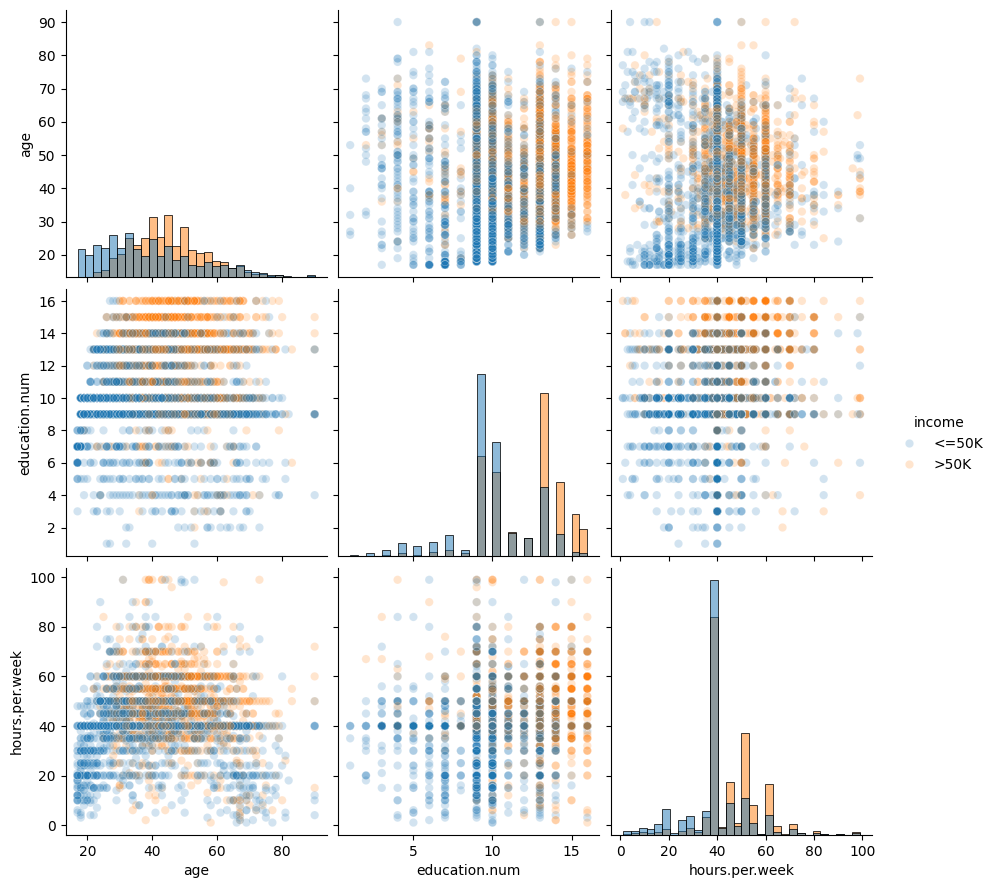

In [ ]:
import seaborn as sns

# Plotamos um subconjunto dos dados para manter o gráfico legível e tornar a
# plotagem mais rápida
n_samples_to_plot = 5000
columns = ["age", "education.num", "hours.per.week"]
_ = sns.pairplot(
    data=adult_census[:n_samples_to_plot],
    vars=columns,
    hue=target_column,
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30},
)

## Criando regras de decisão à mão

Olhando para os gráficos anteriores, poderíamos criar algumas regras escritas
à mão que preveem se alguém tem renda alta ou baixa. Por exemplo, poderíamos
nos concentrar na combinação das features `"hours-per-week"` e `"age"`.

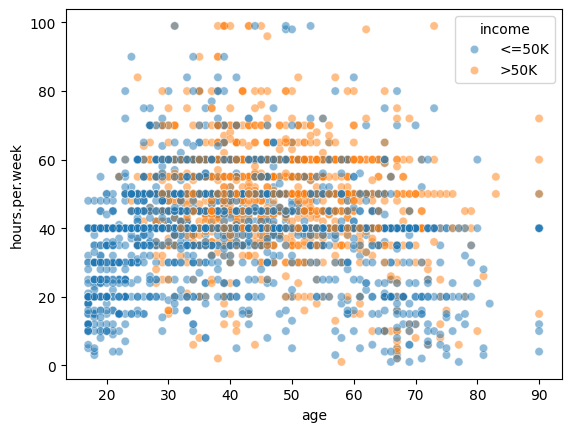

In [ ]:
_ = sns.scatterplot(
    x="age",
    y="hours.per.week",
    data=adult_census[:n_samples_to_plot],
    hue=target_column,
    alpha=0.5,
)

Os pontos de dados (círculos) mostram a distribuição de `"hours-per-week"` e
`"age"` no conjunto de dados. Pontos azuis significam renda baixa e pontos
laranja significam renda alta. Esta parte do gráfico é a mesma do gráfico
inferior esquerdo do pairplot acima.

Neste gráfico, podemos tentar encontrar regiões que contenham principalmente
uma única classe, de modo que possamos decidir facilmente qual classe prever.
Poderíamos chegar a regras escritas à mão como as mostradas neste gráfico:

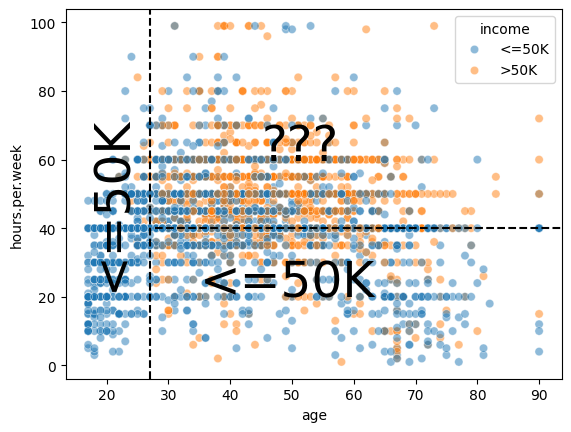

In [ ]:
import matplotlib.pyplot as plt

ax = sns.scatterplot(
    x="age",
    y="hours.per.week",
    data=adult_census[:n_samples_to_plot],
    hue=target_column,
    alpha=0.5,
)

age_limit = 27
plt.axvline(x=age_limit, ymin=0, ymax=1, color="black", linestyle="--")

hours_per_week_limit = 40
plt.axhline(
    y=hours_per_week_limit, xmin=0.18, xmax=1, color="black", linestyle="--"
)

plt.annotate("<=50K", (17, 25), rotation=90, fontsize=35)
plt.annotate("<=50K", (35, 20), fontsize=35)
_ = plt.annotate("???", (45, 60), fontsize=35)

* Na região `age < 27` (região à esquerda), a previsão é renda baixa. De fato,
  há muitos pontos azuis e não conseguimos ver nenhum ponto laranja.
* Na região `age > 27 AND hours-per-week < 40` (região inferior direita), a
  previsão é renda baixa. De fato, há muitos pontos azuis e apenas alguns
  pontos laranja.
* Na região `age > 27 AND hours-per-week > 40` (região superior direita),
  vemos uma mistura de pontos azuis e laranja. Parece complicado escolher qual
  classe deveríamos prever nessa região.

É interessante notar que alguns modelos de aprendizado de máquina funcionam de
forma parecida com o que fizemos: eles são conhecidos como modelos de árvore
de decisão. Os dois limiares que escolhemos (27 anos e 40 horas) são de certa
forma arbitrários, isto é, nós os escolhemos apenas olhando para o pairplot.
Em contraste, uma árvore de decisão escolhe as "melhores" divisões com base
nos dados, sem intervenção ou inspeção humana. Árvores de decisão serão
abordadas com mais detalhes em um módulo futuro.

Note que o aprendizado de máquina é frequentemente usado quando criar regras à
mão não é simples. Por exemplo, porque estamos em alta dimensão (muitas
features em uma tabela) ou porque não existem regras simples e óbvias que
separem as duas classes, como na região superior direita do gráfico anterior.

Resumindo, o importante a lembrar é que, em um cenário de aprendizado de
máquina, o modelo cria automaticamente as "regras" a partir dos dados
existentes para fazer previsões sobre novos dados nunca vistos.

## Recapitulação do notebook

Neste notebook nós:

* carregamos os dados usando API do Kaggle e o `pandas`;
* observamos os diferentes tipos de variáveis para diferenciar entre variáveis
  categóricas e numéricas;
* inspecionamos os dados com o `pandas` e o `seaborn`. A inspeção dos dados
  pode permitir que você decida se usar aprendizado de máquina é apropriado
  para os seus dados e destacar possíveis peculiaridades neles.

Fizemos observações importantes (que serão discutidas mais adiante em
detalhe):

* se a sua variável alvo estiver desbalanceada (por exemplo, você tem mais
  amostras de uma categoria alvo do que de outra), você pode precisar ter
  cuidado ao interpretar os valores das métricas de desempenho;
* colunas podem ser redundantes (ou altamente correlacionadas), o que não é
  necessariamente um problema, mas pode exigir tratamento especial, como
  veremos em notebooks futuros;
* árvores de decisão criam regras de previsão comparando cada feature a um
  valor de limiar, resultando em fronteiras de decisão que são sempre
  paralelas aos eixos. Em 2D, isso significa que as fronteiras são segmentos
  de reta verticais ou horizontais nos valores de limiar das features.